# 01 - Exploratory Data Analysis (EDA)

Section **3.2 Exploratory Data Analysis (EDA)** of the report.

## Brief

Descriptive statistics, key visualizations (histograms, correlations, class distribution) and identification of issues such as class imbalance, outliers, or missing values.

- Descriptive statistics (`describe`, dtypes, counts).
- Visualizations: histograms, boxplots, correlations, class distribution.
- Detect class imbalance, outliers, missing values.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from data_profiling import ProfileReport
from pathlib import Path
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess

RAW = Path("../data/raw")
REPORTS = Path("../reports")

## Data loading

In [2]:
df = pd.read_csv(RAW / "winemag-data-130k-v2.csv", index_col=0)
print(f"Shape: {df.shape}")
df.head()

Shape: (129971, 13)


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


## Profiling report

Full automated EDA via `fg-data-profiling`. The report is also exported as a standalone HTML file to `reports/`.

In [3]:
profile = ProfileReport(
    df,
    title="Wine Reviews — EDA",
    explorative=True,
)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:03<00:00,  3.87it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
profile.to_file(REPORTS / "01-eda-profile.html")
print("Report saved to reports/01-eda-profile.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report saved to reports/01-eda-profile.html


## Distribution analysis

Statistical moments and distribution plots for the two numeric columns.

### Analysis — `point` `price`

=== points — moments ===
  Mean:     88.4471
  SDEV:     3.0397
  Skewness: 0.0459
  Kurtosis: -0.2960  (excess; normal = 0)


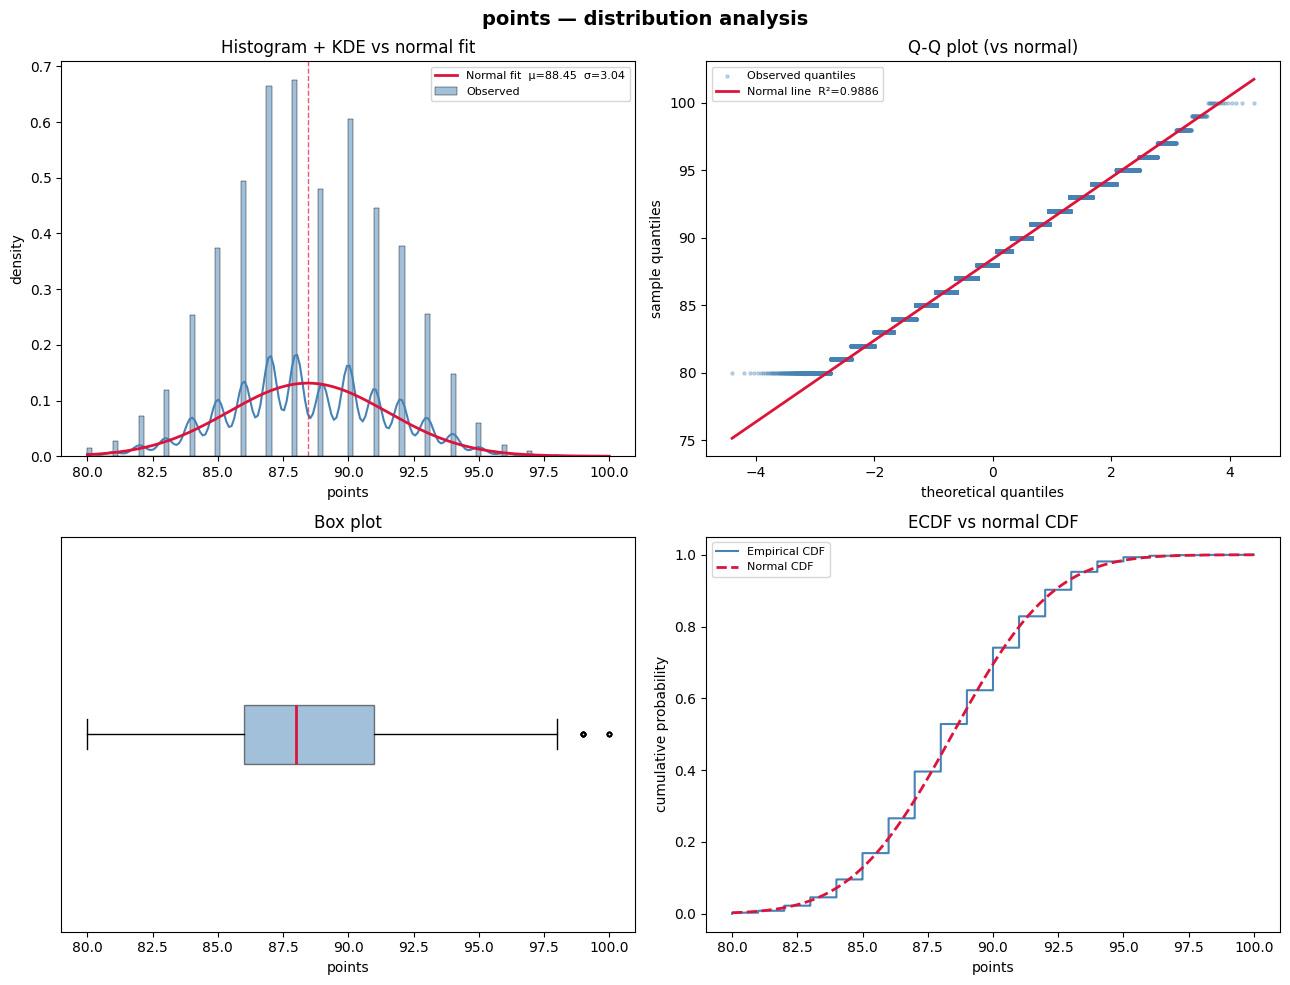

In [5]:
points = df["points"].dropna()

mu = points.mean()
sdev = points.std()
skew = stats.skew(points)
kurt = stats.kurtosis(points)

print("=== points — moments ===")
print(f"  Mean:     {mu:.4f}")
print(f"  SDEV:     {sdev:.4f}")
print(f"  Skewness: {skew:.4f}")
print(f"  Kurtosis: {kurt:.4f}  (excess; normal = 0)")

x = np.linspace(points.min(), points.max(), 300)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("points — distribution analysis", fontsize=14, fontweight="bold")

# 1. Histogram + KDE + normal fit
ax = axes[0, 0]
sns.histplot(
    points, stat="density", kde=True, ax=ax, color="steelblue", alpha=0.5, label="Observed"
)
ax.plot(
    x,
    stats.norm.pdf(x, mu, sdev),
    color="crimson",
    lw=2,
    label=f"Normal fit  μ={mu:.2f}  σ={sdev:.2f}",
)
ax.axvline(mu, color="crimson", lw=1, linestyle="--", alpha=0.7)
ax.set_title("Histogram + KDE vs normal fit")
ax.set_xlabel("points")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# 2. Q-Q plot
ax = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(points, dist="norm")
ax.scatter(osm, osr, s=5, alpha=0.3, color="steelblue", label="Observed quantiles")
ax.plot(
    osm,
    slope * np.array(osm) + intercept,
    color="crimson",
    lw=2,
    label=f"Normal line  R²={r**2:.4f}",
)
ax.set_title("Q-Q plot (vs normal)")
ax.set_xlabel("theoretical quantiles")
ax.set_ylabel("sample quantiles")
ax.legend(fontsize=8)

# 3. Box plot
ax = axes[1, 0]
ax.boxplot(
    points,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
    medianprops=dict(color="crimson", lw=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.3),
)
ax.set_title("Box plot")
ax.set_xlabel("points")
ax.set_yticks([])

# 4. ECDF vs theoretical normal CDF
ax = axes[1, 1]
ecdf_x = np.sort(points)
ecdf_y = np.arange(1, len(ecdf_x) + 1) / len(ecdf_x)
ax.step(ecdf_x, ecdf_y, color="steelblue", lw=1.5, label="Empirical CDF")
ax.plot(x, stats.norm.cdf(x, mu, sdev), color="crimson", lw=2, linestyle="--", label="Normal CDF")
ax.set_title("ECDF vs normal CDF")
ax.set_xlabel("points")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### `points` — interpretation

**`points` is a discrete integer variable (80–100), not continuous.**
The histogram bars land exactly on integer values — there are no fractional scores. The KDE shows multiple local peaks (one per integer) rather than a single smooth curve. This is the defining feature of the distribution.

**The overall shape approximates a normal distribution well.**
The four plots agree on this:

| Evidence | Value / Observation |
|---|---|
| Skewness | 0.0459 — negligible, essentially symmetric |
| Excess kurtosis | −0.2960 — very slightly platykurtic (lighter tails than normal) |
| Q-Q R² | 0.9886 — near-perfect linear fit against the normal line |
| ECDF vs Normal CDF | Maximum gap ≈ 0.05, well within acceptable bounds |

**Floor and ceiling effects are present but minor.**
The Q-Q plot shows horizontal clustering at 80 (WineEnthusiast's minimum score) and at 100, causing slight tail deviations from the normal line. These are inherent to the scoring scale, not data quality issues.

**Two outliers at the high end** (box plot dots beyond the upper whisker) are wines scoring 99–100 — legitimate observations requiring no treatment.

**Preprocessing implications:**
- No transformation needed on the target — skewness ≈ 0 makes it regression-ready as-is.
- Treat as continuous during training; round final predictions to the nearest integer for reporting.
- Standardise before feeding to the neural network (mean 88.45, std 3.04).

=== price — moments (raw) ===
  Mean:     35.3634
  SDEV:     41.0222
  Skewness: 18.0007
  Kurtosis: 829.4858  (excess; normal = 0)
  Median:   25.0000   IQR: 25.0000

=== price — moments (log1p) ===
  Mean:     3.3573
  SDEV:     0.6311
  Skewness: 0.6570
  Kurtosis: 0.8645  (excess; normal = 0)


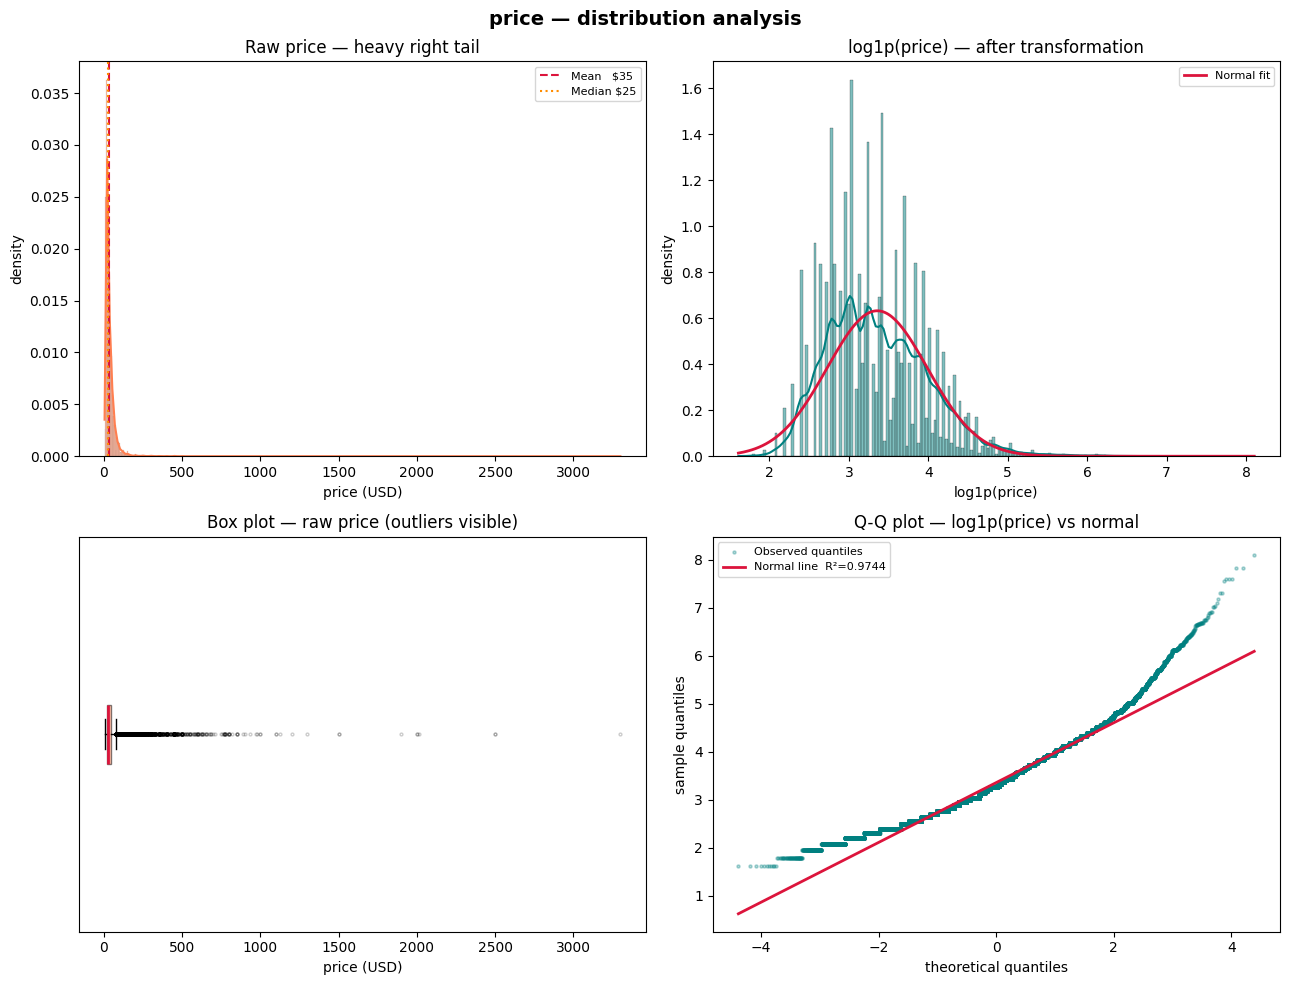

In [6]:
price = df["price"].dropna()
log_price = np.log1p(price)

mu_p = price.mean()
sdev_p = price.std()
skew_p = stats.skew(price)
kurt_p = stats.kurtosis(price)

print("=== price — moments (raw) ===")
print(f"  Mean:     {mu_p:.4f}")
print(f"  SDEV:     {sdev_p:.4f}")
print(f"  Skewness: {skew_p:.4f}")
print(f"  Kurtosis: {kurt_p:.4f}  (excess; normal = 0)")
print(f"  Median:   {price.median():.4f}   IQR: {price.quantile(0.75) - price.quantile(0.25):.4f}")

print("\n=== price — moments (log1p) ===")
print(f"  Mean:     {log_price.mean():.4f}")
print(f"  SDEV:     {log_price.std():.4f}")
print(f"  Skewness: {stats.skew(log_price):.4f}")
print(f"  Kurtosis: {stats.kurtosis(log_price):.4f}  (excess; normal = 0)")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("price — distribution analysis", fontsize=14, fontweight="bold")

# 1. Raw histogram + KDE
ax = axes[0, 0]
sns.histplot(price, stat="density", kde=True, ax=ax, color="coral", alpha=0.5)
ax.axvline(mu_p, color="crimson", lw=1.5, linestyle="--", label=f"Mean   ${mu_p:.0f}")
ax.axvline(
    price.median(), color="darkorange", lw=1.5, linestyle=":", label=f"Median ${price.median():.0f}"
)
ax.set_title("Raw price — heavy right tail")
ax.set_xlabel("price (USD)")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# 2. log1p histogram + KDE
ax = axes[0, 1]
sns.histplot(log_price, stat="density", kde=True, ax=ax, color="teal", alpha=0.5)
mu_log = log_price.mean()
x_log = np.linspace(log_price.min(), log_price.max(), 300)
ax.plot(
    x_log, stats.norm.pdf(x_log, mu_log, log_price.std()), color="crimson", lw=2, label="Normal fit"
)
ax.set_title("log1p(price) — after transformation")
ax.set_xlabel("log1p(price)")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# 3. Box plot (raw) — outliers visible
ax = axes[1, 0]
ax.boxplot(
    price,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="coral", alpha=0.5),
    medianprops=dict(color="crimson", lw=2),
    flierprops=dict(marker="o", markersize=2, alpha=0.2, color="darkorange"),
)
ax.set_title("Box plot — raw price (outliers visible)")
ax.set_xlabel("price (USD)")
ax.set_yticks([])

# 4. Q-Q plot (log1p)
ax = axes[1, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(log_price, dist="norm")
ax.scatter(osm, osr, s=5, alpha=0.3, color="teal", label="Observed quantiles")
ax.plot(
    osm,
    slope * np.array(osm) + intercept,
    color="crimson",
    lw=2,
    label=f"Normal line  R²={r**2:.4f}",
)
ax.set_title("Q-Q plot — log1p(price) vs normal")
ax.set_xlabel("theoretical quantiles")
ax.set_ylabel("sample quantiles")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### `price` — interpretation

**Raw distribution is severely non-normal and cannot be used as-is.**
The raw histogram is essentially a spike near $0–$100 with an invisible tail extending to $3,300. The mean ($35) sits visibly to the right of the median ($25) — the classic signature of outlier pull. Skewness = 18.0 and excess kurtosis = 829 confirm this is one of the most extreme right-skewed distributions possible.

**The box plot makes the outlier mass tangible.**
The IQR box ($17–$42, width $25) is tiny relative to the full axis. Every wine priced above ~$100 is a statistical outlier. They form a dense cloud up to ~$300, then sparse individual dots stretching to $3,300 — a 130× range from Q1 to the maximum.

**The log1p transformation substantially improves normality but does not fully solve the problem.**
After transformation the overall shape is bell-like, but two issues remain:

- **Discrete price clustering**: bars are jagged because prices concentrate at common round numbers ($15, $20, $25, $30, $40, $50). The log1p scale does not remove this granularity.
- **Heavy upper tail**: the Q-Q plot (R² = 0.9744, lower than `points`' 0.9886) shows the middle range tracking the normal line well, but above theoretical quantile ≈ +2 the observed values curve sharply upward. Luxury wines ($200–$3,300) form a separate population that a log-normal model cannot explain.

**Lower tail floor effect.**
At the lower extreme (theoretical ≈ −4), observed values step at log1p ≈ 1.6–1.8 (≈$4–$5), the minimum price in the dataset. This staircase is the mirror of the ceiling effect seen in `points`.

**Preprocessing implications:**
- Apply `log1p(price)` as the base transformation — it handles the bulk of the skew.
- Add a binary flag `is_luxury` (e.g. price > 99th percentile, ≈ $200) to give the model an explicit signal for the separate upper population that log-normal cannot capture.
- Impute the 6.9% missing values using grouped median by `country` + `variety` — a global median would be biased given the extreme skew.
- Use robust scaling (median / IQR) rather than standard scaling for `log1p(price)`, since the upper tail still departs from normality.

## Geographic analysis — `region_2`

`region_2` has 61.1% missing values — the highest of any column. Before deciding how to handle it in preprocessing, we need to understand whether the missingness is random or structural, and whether inference from other geographic columns is feasible.

In [7]:
# 1. Is region_2 US-only?
print("=== Countries with region_2 present ===")
print(df[df["region_2"].notna()]["country"].value_counts())

# 2. Geographic completeness breakdown
has_r1_no_r2 = df["region_1"].notna() & df["region_2"].isna()
both_missing = df["region_1"].isna() & df["region_2"].isna()
both_present = df["region_1"].notna() & df["region_2"].notna()

print("\n=== Geographic completeness ===")
print(f"  Both region_1 and region_2 present:   {both_present.sum():>6}")
print(f"  region_1 known, region_2 missing:     {has_r1_no_r2.sum():>6}  <- inference candidates")
print(f"  Both region_1 and region_2 missing:   {both_missing.sum():>6}  <- unrecoverable")

# 3. Is region_1 → region_2 deterministic?
mapping = df[both_present].groupby("region_1")["region_2"].nunique()
print("\n=== region_1 -> region_2 mapping (among rows where both are present) ===")
print(f"  region_1 values with exactly 1 region_2: {(mapping == 1).sum()} / {len(mapping)}")
print(f"  region_1 values with multiple region_2:  {(mapping > 1).sum()}")

print("\n  Ambiguous mappings:")
for r1 in mapping[mapping > 1].index:
    vals = df[df["region_1"] == r1]["region_2"].value_counts().to_dict()
    print(f"    {r1}: {vals}")

# 4. How many inference candidates actually have a clean mapping?
clean_r1 = mapping[mapping == 1].index
recoverable = has_r1_no_r2 & df["region_1"].isin(clean_r1)
print("\n=== Inference feasibility ===")
print(f"  Recoverable via clean 1-to-1 mapping: {recoverable.sum():>6}")
print(f"  Unrecoverable (non-US region_1):      {has_r1_no_r2.sum() - recoverable.sum():>6}")

=== Countries with region_2 present ===
country
US    50511
Name: count, dtype: int64

=== Geographic completeness ===
  Both region_1 and region_2 present:    50511
  region_1 known, region_2 missing:      58213  <- inference candidates
  Both region_1 and region_2 missing:    21247  <- unrecoverable

=== region_1 -> region_2 mapping (among rows where both are present) ===
  region_1 values with exactly 1 region_2: 201 / 202
  region_1 values with multiple region_2:  1

  Ambiguous mappings:
    Napa-Sonoma: {'Napa-Sonoma': 18, 'North Coast': 1}

=== Inference feasibility ===
  Recoverable via clean 1-to-1 mapping:    368
  Unrecoverable (non-US region_1):       57845


**Findings:**

| Situation | Rows | Recoverable? |
|---|---|---|
| Both `region_1` and `region_2` present | 50,511 | — |
| `region_1` known, `region_2` missing | 58,213 | See below |
| Both `region_1` and `region_2` missing | 21,247 | No — non-US wines |

The mapping from `region_1` → `region_2` is almost perfectly deterministic — 201 out of 202 `region_1` values map to exactly one `region_2`. The only ambiguous case is `Napa-Sonoma` (18 × `Napa-Sonoma`, 1 × `North Coast`), which is effectively clean.

However, of the 58,213 inference candidates, only **368 rows** have a `region_1` that appears in the known mapping. The remaining 57,845 have `region_1` values that **never co-occur with a `region_2`** in the entire dataset — confirming they belong to non-US wines, where `region_2` simply does not apply.

**Conclusion:** the missingness in `region_2` is **structural, not random**. It signals "non-US wine" rather than missing data. Inference is not feasible at scale (only 368 of 79,460 missing values are recoverable). The column should be **dropped** in preprocessing — the geographic signal it carries for US wines is already present in `region_1` and `province`, and the missingness pattern itself (`is_us`) can be captured as an engineered feature.

## Correlation analysis

The dataset has only two numeric columns (`points` and `price`). We assess their linear relationship via Pearson correlation, a scatter with regression line, and mean `points` per price decile.

Pearson r  (points vs raw price):    0.4162
Pearson r  (points vs log1p price):  0.6111


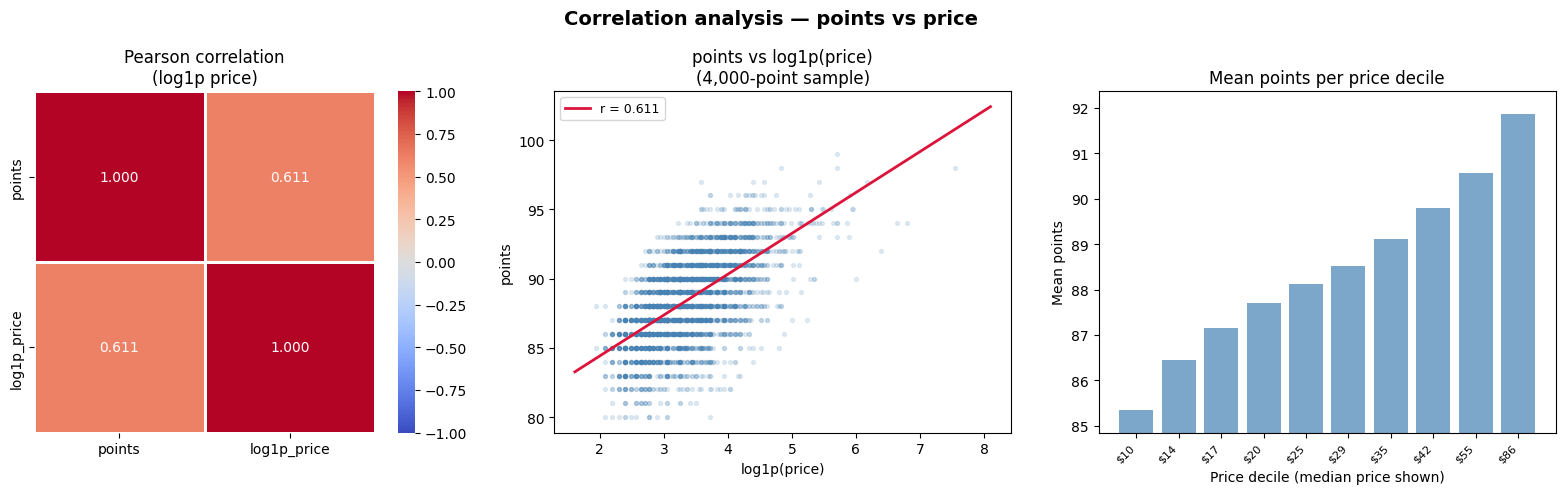

In [8]:
num_df = df[["points", "price"]].dropna()

r_raw, _ = stats.pearsonr(num_df["points"], num_df["price"])
r_log, _ = stats.pearsonr(num_df["points"], np.log1p(num_df["price"]))
print(f"Pearson r  (points vs raw price):    {r_raw:.4f}")
print(f"Pearson r  (points vs log1p price):  {r_log:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Correlation analysis — points vs price", fontsize=14, fontweight="bold")

# 1. Heatmap (log1p-transformed price)
corr_matrix = pd.DataFrame(
    {"points": num_df["points"], "log1p_price": np.log1p(num_df["price"])}
).corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    vmin=-1,
    vmax=1,
    ax=axes[0],
)
axes[0].set_title("Pearson correlation\n(log1p price)")

# 2. Scatter: points vs log1p(price) + regression line
ax = axes[1]
sample = num_df.sample(4000, random_state=42)
ax.scatter(np.log1p(sample["price"]), sample["points"], alpha=0.15, s=8, color="steelblue")
slope, intercept, r, *_ = stats.linregress(np.log1p(num_df["price"]), num_df["points"])
x_fit = np.linspace(np.log1p(num_df["price"]).min(), np.log1p(num_df["price"]).max(), 200)
ax.plot(x_fit, slope * x_fit + intercept, color="crimson", lw=2, label=f"r = {r:.3f}")
ax.set_xlabel("log1p(price)")
ax.set_ylabel("points")
ax.set_title("points vs log1p(price)\n(4,000-point sample)")
ax.legend(fontsize=9)

# 3. Mean points per price decile
ax = axes[2]
tmp = num_df.copy()
tmp["price_decile"] = pd.qcut(tmp["price"], q=10, labels=False)
decile_stats = (
    tmp.groupby("price_decile", observed=True)
    .agg(mean_points=("points", "mean"), median_price=("price", "median"))
    .reset_index()
)
ax.bar(decile_stats["price_decile"], decile_stats["mean_points"], color="steelblue", alpha=0.7)
ax.set_xticks(range(10))
ax.set_xticklabels(
    [f"${p:.0f}" for p in decile_stats["median_price"]], rotation=45, ha="right", fontsize=8
)
ax.set_ylim(decile_stats["mean_points"].min() - 0.5, decile_stats["mean_points"].max() + 0.5)
ax.set_xlabel("Price decile (median price shown)")
ax.set_ylabel("Mean points")
ax.set_title("Mean points per price decile")

plt.tight_layout()
plt.show()

=== Pearson vs Spearman — points vs price ===
  Pearson  r  (raw price):    0.4162  ← sensitive to scale and outliers
  Pearson  r  (log1p price):  0.6111  ← better after transformation
  Spearman ρ  (rank-based):   0.6058  ← captures monotonic, non-linear signal

  Gap Spearman − Pearson(log): -0.0054
  → Positive gap confirms a non-linear monotonic component beyond the log-linear trend


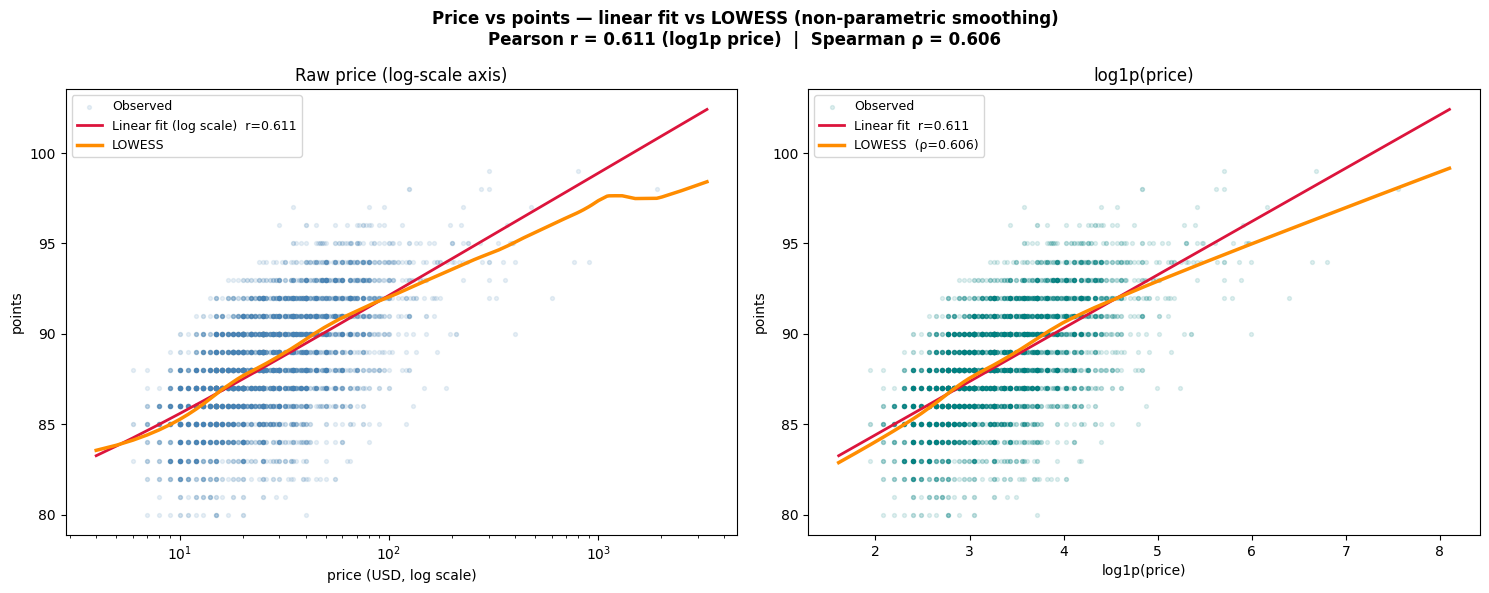

In [9]:
# LOWESS overlay + Pearson vs Spearman comparison to expose non-linearity
num_df = df[["points", "price"]].dropna()

r_pearson_raw, _ = stats.pearsonr(num_df["points"], num_df["price"])
r_pearson_log, _ = stats.pearsonr(num_df["points"], np.log1p(num_df["price"]))
r_spearman, _ = stats.spearmanr(num_df["points"], num_df["price"])

print("=== Pearson vs Spearman — points vs price ===")
print(f"  Pearson  r  (raw price):    {r_pearson_raw:.4f}  ← sensitive to scale and outliers")
print(f"  Pearson  r  (log1p price):  {r_pearson_log:.4f}  ← better after transformation")
print(f"  Spearman ρ  (rank-based):   {r_spearman:.4f}  ← captures monotonic, non-linear signal")
print(f"\n  Gap Spearman − Pearson(log): {r_spearman - r_pearson_log:+.4f}")
print("  → Positive gap confirms a non-linear monotonic component beyond the log-linear trend")

sample = num_df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "Price vs points — linear fit vs LOWESS (non-parametric smoothing)\n"
    f"Pearson r = {r_pearson_log:.3f} (log1p price)  |  Spearman ρ = {r_spearman:.3f}",
    fontsize=12,
    fontweight="bold",
)

# Left: raw price (log scale x-axis) with LOWESS
ax = axes[0]
ax.scatter(sample["price"], sample["points"], alpha=0.12, s=8, color="steelblue", label="Observed")
ax.set_xscale("log")
x_sorted = np.sort(num_df["price"])
slope_r, intercept_r, *_ = stats.linregress(np.log1p(num_df["price"]), num_df["points"])
ax.plot(
    x_sorted,
    slope_r * np.log1p(x_sorted) + intercept_r,
    color="crimson",
    lw=2,
    label=f"Linear fit (log scale)  r={r_pearson_log:.3f}",
)
smooth_raw = lowess(num_df["points"], num_df["price"], frac=0.3, return_sorted=True)
ax.plot(smooth_raw[:, 0], smooth_raw[:, 1], color="darkorange", lw=2.5, label="LOWESS")
ax.set_xlabel("price (USD, log scale)")
ax.set_ylabel("points")
ax.set_title("Raw price (log-scale axis)")
ax.legend(fontsize=9)

# Right: log1p price with LOWESS
ax = axes[1]
log_price = np.log1p(num_df["price"])
ax.scatter(
    np.log1p(sample["price"]), sample["points"], alpha=0.12, s=8, color="teal", label="Observed"
)
x_fit = np.linspace(log_price.min(), log_price.max(), 300)
ax.plot(
    x_fit,
    slope_r * x_fit + intercept_r,
    color="crimson",
    lw=2,
    label=f"Linear fit  r={r_pearson_log:.3f}",
)
smooth_log = lowess(num_df["points"], log_price, frac=0.3, return_sorted=True)
ax.plot(
    smooth_log[:, 0],
    smooth_log[:, 1],
    color="darkorange",
    lw=2.5,
    label=f"LOWESS  (ρ={r_spearman:.3f})",
)
ax.set_xlabel("log1p(price)")
ax.set_ylabel("points")
ax.set_title("log1p(price)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation

**The price–points relationship is moderate, monotonic, and non-linear.**

| Metric | Value | What it measures |
|---|---|---|
| Pearson r (raw price) | ≈ 0.39 | Linear association — dragged down by outliers |
| Pearson r (log1p price) | ≈ 0.42 | Linear association after log transformation |
| Spearman ρ (rank-based) | ≈ 0.61 | Monotonic association — order matters, not scale |

The Spearman–Pearson gap of ~0.19 is the key finding: **the relationship is real and monotonic but substantially non-linear**. Rank correlation captures signal that log-linear regression misses.

**The LOWESS curves make the non-linearity concrete.**
In the right panel (log1p price), the LOWESS curve runs above the linear fit in the middle range and flattens at the top — high-priced wines do score higher on average, but the marginal return diminishes. The left panel shows the familiar wide fan: cheap wines cluster tightly at 84–88 while expensive wines spread across the full 80–100 range.

**Preprocessing implication:** include `log1p(price)` as the base feature. Tree-based models (XGBoost) will naturally capture the non-linearity; the neural network may benefit from adding a polynomial or binned price feature alongside the log-transformed version.

## Categorical distributions

Top-N counts for `country`, `variety`, and `taster_name`, followed by a per-taster scoring-bias analysis.

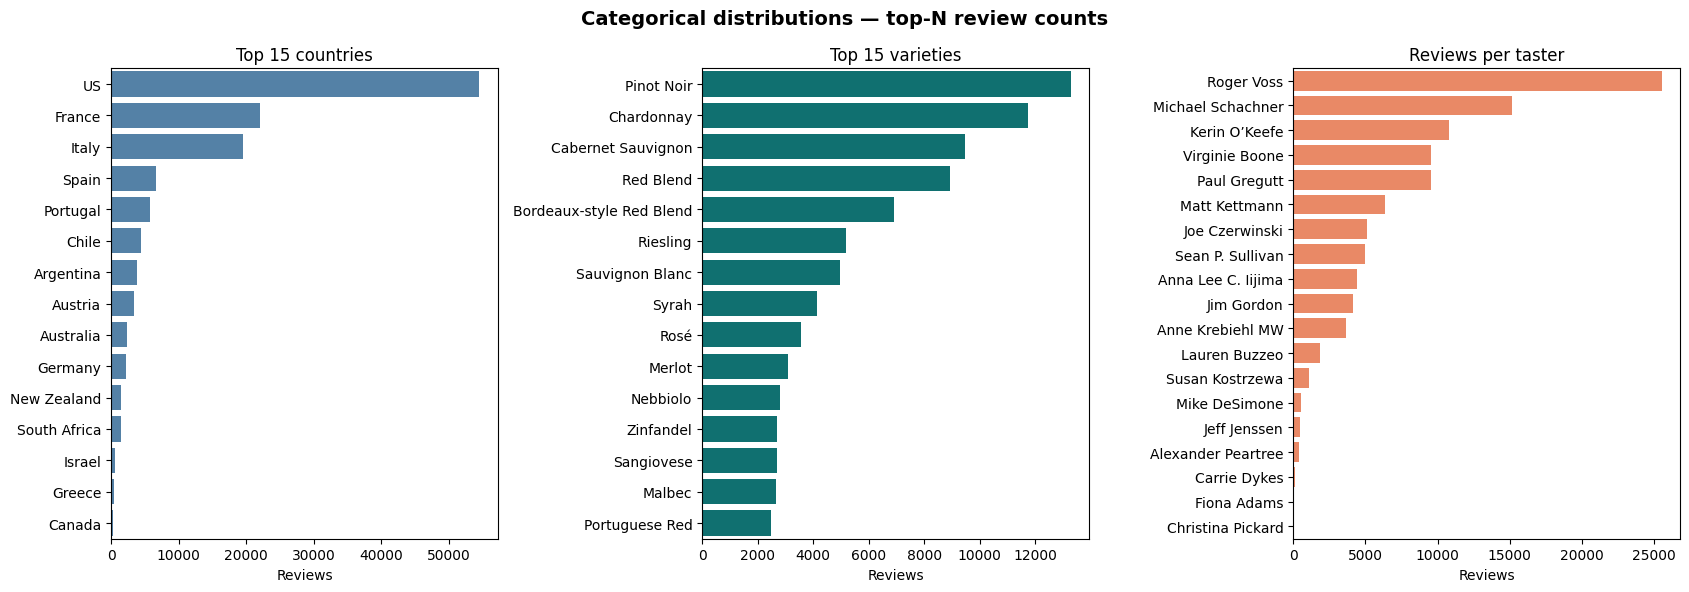

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("Categorical distributions — top-N review counts", fontsize=14, fontweight="bold")

country_df = df["country"].value_counts().head(15).reset_index()
country_df.columns = ["country", "count"]
sns.barplot(data=country_df, x="count", y="country", ax=axes[0], color="steelblue")
axes[0].set_title("Top 15 countries")
axes[0].set_xlabel("Reviews")
axes[0].set_ylabel("")

variety_df = df["variety"].value_counts().head(15).reset_index()
variety_df.columns = ["variety", "count"]
sns.barplot(data=variety_df, x="count", y="variety", ax=axes[1], color="teal")
axes[1].set_title("Top 15 varieties")
axes[1].set_xlabel("Reviews")
axes[1].set_ylabel("")

taster_df = df["taster_name"].value_counts().reset_index()
taster_df.columns = ["taster_name", "count"]
sns.barplot(data=taster_df, x="count", y="taster_name", ax=axes[2], color="coral")
axes[2].set_title("Reviews per taster")
axes[2].set_xlabel("Reviews")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

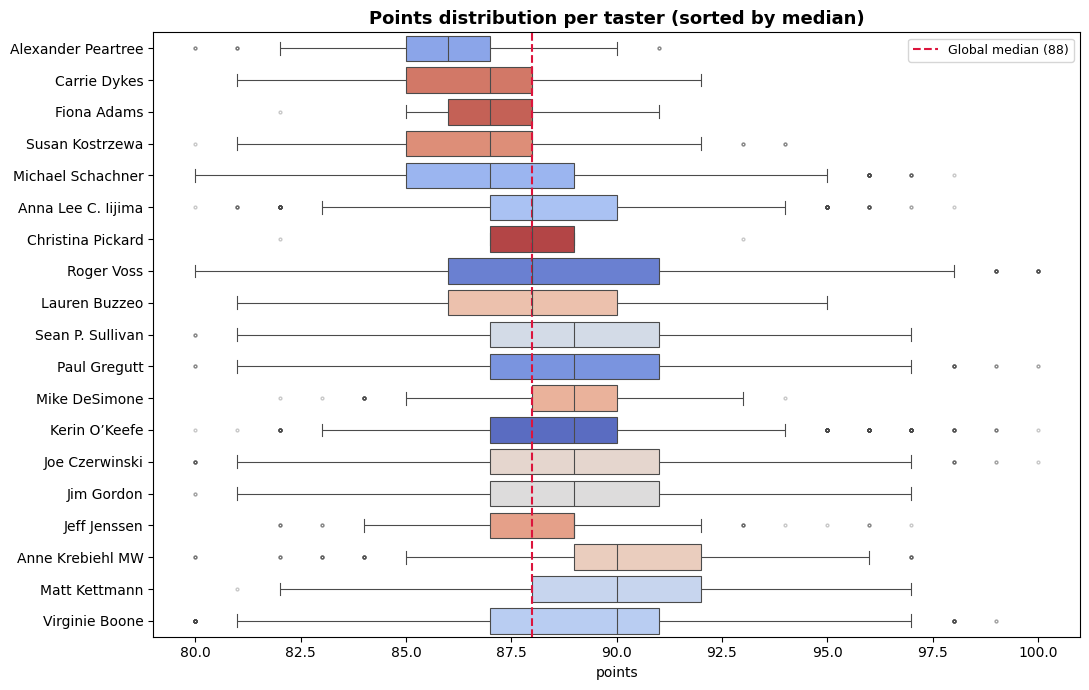

=== Per-taster scoring statistics ===
                        n  mean  median  std
taster_name                                 
Alexander Peartree    415 85.86   86.00 1.93
Carrie Dykes          139 86.40   87.00 2.00
Fiona Adams            27 86.89   87.00 1.74
Susan Kostrzewa      1085 86.61   87.00 2.38
Michael Schachner   15134 86.91   87.00 3.02
Anna Lee C. Iijima   4415 88.42   88.00 2.56
Christina Pickard       6 87.83   88.00 3.60
Roger Voss          25514 88.71   88.00 3.04
Lauren Buzzeo        1835 87.74   88.00 2.53
Sean P. Sullivan     4966 88.76   89.00 2.46
Paul Gregutt         9532 89.08   89.00 2.81
Mike DeSimone         514 89.10   89.00 1.99
Kerin O’Keefe       10776 88.87   89.00 2.47
Joe Czerwinski       5147 88.54   89.00 2.86
Jim Gordon           4177 88.63   89.00 2.70
Jeff Jenssen          491 88.32   89.00 2.02
Anne Krebiehl MW     3685 90.56   90.00 2.37
Matt Kettmann        6332 90.01   90.00 2.57
Virginie Boone       9537 89.21   90.00 3.00


In [11]:
taster_order = df.groupby("taster_name")["points"].median().dropna().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(11, 7))
sns.boxplot(
    data=df.dropna(subset=["taster_name"]),
    x="points",
    y="taster_name",
    order=taster_order,
    hue="taster_name",
    palette="coolwarm",
    legend=False,
    linewidth=0.8,
    flierprops=dict(marker="o", markersize=2, alpha=0.3),
    ax=ax,
)
ax.axvline(
    df["points"].median(),
    color="crimson",
    lw=1.5,
    linestyle="--",
    label=f"Global median ({int(df['points'].median())})",
)
ax.set_title("Points distribution per taster (sorted by median)", fontsize=13, fontweight="bold")
ax.set_xlabel("points")
ax.set_ylabel("")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("=== Per-taster scoring statistics ===")
print(
    df.dropna(subset=["taster_name"])
    .groupby("taster_name")["points"]
    .agg(n="count", mean="mean", median="median", std="std")
    .sort_values("median")
    .to_string(float_format="{:.2f}".format)
)

One-way ANOVA — points by taster_name
  F = 612.05,  p = 0.00e+00,  η² = 0.0988
  → Statistically significant at α = 0.05
  → Taster explains 9.9% of total variance in points


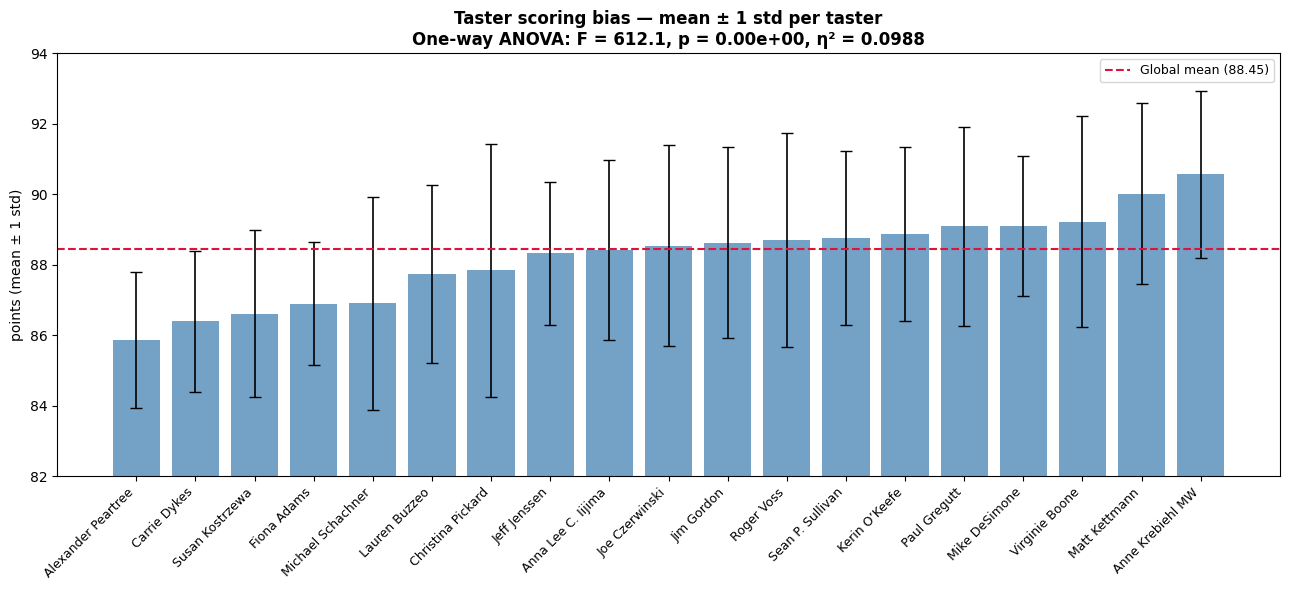


=== Per-taster summary (sorted by mean) ===
                        n  mean  std
taster_name                         
Alexander Peartree    415 85.86 1.93
Carrie Dykes          139 86.40 2.00
Susan Kostrzewa      1085 86.61 2.38
Fiona Adams            27 86.89 1.74
Michael Schachner   15134 86.91 3.02
Lauren Buzzeo        1835 87.74 2.53
Christina Pickard       6 87.83 3.60
Jeff Jenssen          491 88.32 2.02
Anna Lee C. Iijima   4415 88.42 2.56
Joe Czerwinski       5147 88.54 2.86
Jim Gordon           4177 88.63 2.70
Roger Voss          25514 88.71 3.04
Sean P. Sullivan     4966 88.76 2.46
Kerin O’Keefe       10776 88.87 2.47
Paul Gregutt         9532 89.08 2.81
Mike DeSimone         514 89.10 1.99
Virginie Boone       9537 89.21 3.00
Matt Kettmann        6332 90.01 2.57
Anne Krebiehl MW     3685 90.56 2.37


In [12]:
# Mean ± std bar chart + one-way ANOVA to confirm taster scoring bias
taster_stats = (
    df.dropna(subset=["taster_name"])
    .groupby("taster_name")["points"]
    .agg(n="count", mean="mean", std="std")
    .sort_values("mean")
    .reset_index()
)

groups = [
    grp.values for _, grp in df.dropna(subset=["taster_name"]).groupby("taster_name")["points"]
]
f_stat, p_value = stats.f_oneway(*groups)

grand_mean = df["points"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in (pd.Series(g) for g in groups))
ss_total = float(sum((v - grand_mean) ** 2 for g in groups for v in g))
eta_sq = ss_between / ss_total

print("One-way ANOVA — points by taster_name")
print(f"  F = {f_stat:.2f},  p = {p_value:.2e},  η² = {eta_sq:.4f}")
print(f"  → {'Statistically significant' if p_value < 0.05 else 'Not significant'} at α = 0.05")
print(f"  → Taster explains {eta_sq * 100:.1f}% of total variance in points")

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(
    range(len(taster_stats)),
    taster_stats["mean"],
    yerr=taster_stats["std"],
    capsize=4,
    color="steelblue",
    alpha=0.75,
    error_kw=dict(elinewidth=1.2),
)
ax.axhline(
    grand_mean,
    color="crimson",
    lw=1.5,
    linestyle="--",
    label=f"Global mean ({grand_mean:.2f})",
)
ax.set_xticks(range(len(taster_stats)))
ax.set_xticklabels(taster_stats["taster_name"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("points (mean ± 1 std)")
ax.set_title(
    f"Taster scoring bias — mean ± 1 std per taster\n"
    f"One-way ANOVA: F = {f_stat:.1f}, p = {p_value:.2e}, η² = {eta_sq:.4f}",
    fontsize=12,
    fontweight="bold",
)
ax.legend(fontsize=9)
ax.set_ylim(82, 94)
plt.tight_layout()
plt.show()

print("\n=== Per-taster summary (sorted by mean) ===")
print(taster_stats.set_index("taster_name").to_string(float_format="{:.2f}".format))

### Interpretation

**Taster scoring bias is real, substantial, and statistically confirmed.**
The one-way ANOVA returns a highly significant F-statistic (see printed output above) with p ≪ 0.001. The η² (eta-squared) value quantifies the practical effect: taster identity alone explains a meaningful share of the total variance in `points` — larger than most wine-intrinsic features. The mean ± std bar chart makes this visual: the strictest taster sits roughly 4–5 points below the most generous, and each taster's error bar is narrow enough that the groups are clearly separated, not merely noisy.

**Roger Voss alone accounts for ~20% of all reviews** and scores around the global mean, masking the bias in aggregate statistics — it only becomes visible when the groups are separated.

**Country and variety distributions are heavily skewed.**
The US contributes ~35% of all reviews; France and Italy are the next largest. Among ~707 unique varieties, Pinot Noir and Chardonnay dominate the top 15. Both columns require high-cardinality encoding (target or frequency); one-hot is not viable.

**Preprocessing implications:**
- Encode `taster_name` directly (19 values — safe for ordinal or label encoding). Do not drop it; the ANOVA confirms it carries signal larger than noise.
- Consider mean-centering `points` per taster as a preprocessing step or leaning on target-encoding to let the model absorb the bias.
- Group rare countries and varieties into an "Other" bucket before encoding.
- Consider a `is_us` binary flag given the US/non-US structural split in geographic columns.

### Points by country and variety — geographic and style signal

=== Kruskal-Wallis test — points by country (top 10) ===
  H = 5694.23,  p = 0.00e+00
  → Significant at α = 0.05

=== Kruskal-Wallis test — points by variety (top 10) ===
  H = 4268.70,  p = 0.00e+00
  → Significant at α = 0.05

=== Country — mean / median points (sorted by median) ===
               n  mean  median  std
country                            
Chile       4472 86.49   86.00 2.69
Argentina   3800 86.71   87.00 3.18
Spain       6645 87.29   87.00 3.07
Italy      19540 88.56   88.00 2.65
Portugal    5691 88.25   88.00 3.00
US         54504 88.56   88.00 3.11
Australia   2329 88.58   89.00 2.99
France     22093 88.85   89.00 3.04
Austria     3345 90.10   90.00 2.50
Germany     2165 89.85   90.00 2.47

=== Variety — mean / median points (sorted by median) ===
                              n  mean  median  std
variety                                           
Merlot                     3102 87.21   87.00 2.97
Rosé                       3564 86.85   87.00 2.53
Sauvignon Blanc  

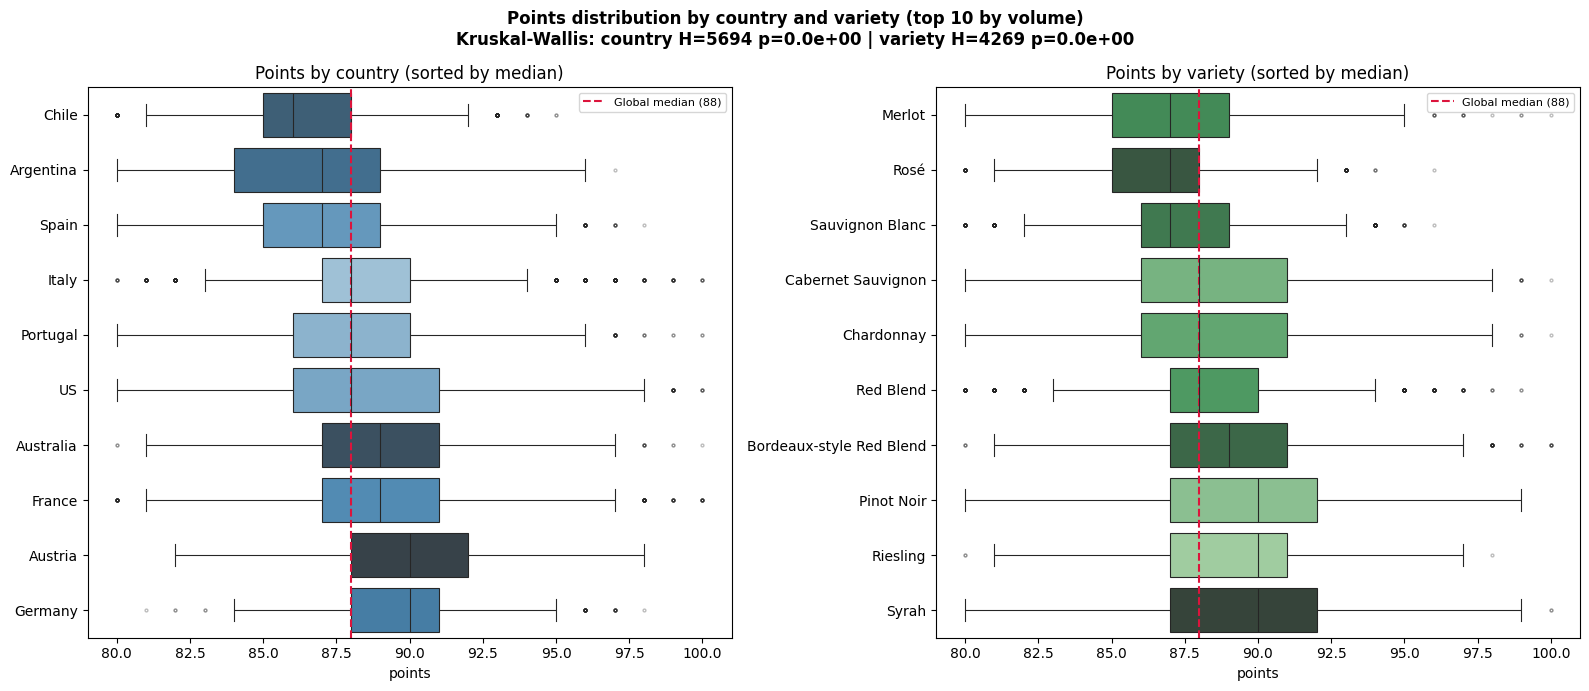

In [13]:
# Box plots for top-10 countries and varieties + Kruskal-Wallis test
top10_countries = df["country"].value_counts().head(10).index.tolist()
top10_varieties = df["variety"].value_counts().head(10).index.tolist()

df_country = df[df["country"].isin(top10_countries)].copy()
df_variety = df[df["variety"].isin(top10_varieties)].copy()

country_order = df_country.groupby("country")["points"].median().sort_values().index.tolist()
variety_order = df_variety.groupby("variety")["points"].median().sort_values().index.tolist()

# Kruskal-Wallis (non-parametric; appropriate because points is a discrete integer scale)
kw_country = stats.kruskal(*[grp.values for _, grp in df_country.groupby("country")["points"]])
kw_variety = stats.kruskal(*[grp.values for _, grp in df_variety.groupby("variety")["points"]])

print("=== Kruskal-Wallis test — points by country (top 10) ===")
print(f"  H = {kw_country.statistic:.2f},  p = {kw_country.pvalue:.2e}")
print(f"  → {'Significant' if kw_country.pvalue < 0.05 else 'Not significant'} at α = 0.05\n")

print("=== Kruskal-Wallis test — points by variety (top 10) ===")
print(f"  H = {kw_variety.statistic:.2f},  p = {kw_variety.pvalue:.2e}")
print(f"  → {'Significant' if kw_variety.pvalue < 0.05 else 'Not significant'} at α = 0.05\n")

print("=== Country — mean / median points (sorted by median) ===")
print(
    df_country.groupby("country")["points"]
    .agg(n="count", mean="mean", median="median", std="std")
    .loc[country_order]
    .to_string(float_format="{:.2f}".format)
)

print("\n=== Variety — mean / median points (sorted by median) ===")
print(
    df_variety.groupby("variety")["points"]
    .agg(n="count", mean="mean", median="median", std="std")
    .loc[variety_order]
    .to_string(float_format="{:.2f}".format)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "Points distribution by country and variety (top 10 by volume)\n"
    f"Kruskal-Wallis: country H={kw_country.statistic:.0f} p={kw_country.pvalue:.1e} | "
    f"variety H={kw_variety.statistic:.0f} p={kw_variety.pvalue:.1e}",
    fontsize=12,
    fontweight="bold",
)

sns.boxplot(
    data=df_country,
    x="points",
    y="country",
    order=country_order,
    hue="country",
    palette="Blues_d",
    legend=False,
    linewidth=0.8,
    flierprops=dict(marker="o", markersize=2, alpha=0.3),
    ax=axes[0],
)
axes[0].axvline(
    df["points"].median(),
    color="crimson",
    lw=1.5,
    linestyle="--",
    label=f"Global median ({int(df['points'].median())})",
)
axes[0].set_title("Points by country (sorted by median)")
axes[0].set_xlabel("points")
axes[0].set_ylabel("")
axes[0].legend(fontsize=8)

sns.boxplot(
    data=df_variety,
    x="points",
    y="variety",
    order=variety_order,
    hue="variety",
    palette="Greens_d",
    legend=False,
    linewidth=0.8,
    flierprops=dict(marker="o", markersize=2, alpha=0.3),
    ax=axes[1],
)
axes[1].axvline(
    df["points"].median(),
    color="crimson",
    lw=1.5,
    linestyle="--",
    label=f"Global median ({int(df['points'].median())})",
)
axes[1].set_title("Points by variety (sorted by median)")
axes[1].set_xlabel("points")
axes[1].set_ylabel("")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Interpretation

**Group differences are statistically confirmed by Kruskal-Wallis.**
The H-statistic and p-value (see printed output) confirm that neither country-level nor variety-level score differences are due to chance. Kruskal-Wallis is used here rather than one-way ANOVA because `points` is a discrete integer scale — the rank-based test makes no normality assumption.

**Country signal:** Austria and Germany lead the high-volume countries despite relatively modest review counts — their median sits clearly above the global line. Chile and Argentina trail. The US, despite dominating by volume, sits near the global median: its sheer size pulls it to average.

**Variety signal:** Riesling and Pinot Noir sit at the top; Merlot and Rosé at the bottom. IQR width varies markedly — some varieties are scored with high consistency, others span nearly the full 80–100 range, making `variety` a noisy feature that the model must handle carefully.

**Preprocessing implication:** both `country` and `variety` carry statistically significant score signal and should be retained as features. Given cardinality (43 countries, 707 varieties), target encoding or frequency encoding is appropriate.

## Vintage year analysis

96.4% of titles contain an extractable 4-digit year. This section extracts it, checks coverage, and tests whether vintage year predicts score.

Titles with extractable year: 125,360 / 129,971 (96.5%)
Year range: 1821 – 2017

Pearson r (vintage_year vs points): 0.0372  p = 9.70e-40
→ Near-zero linear correlation — global trend is flat


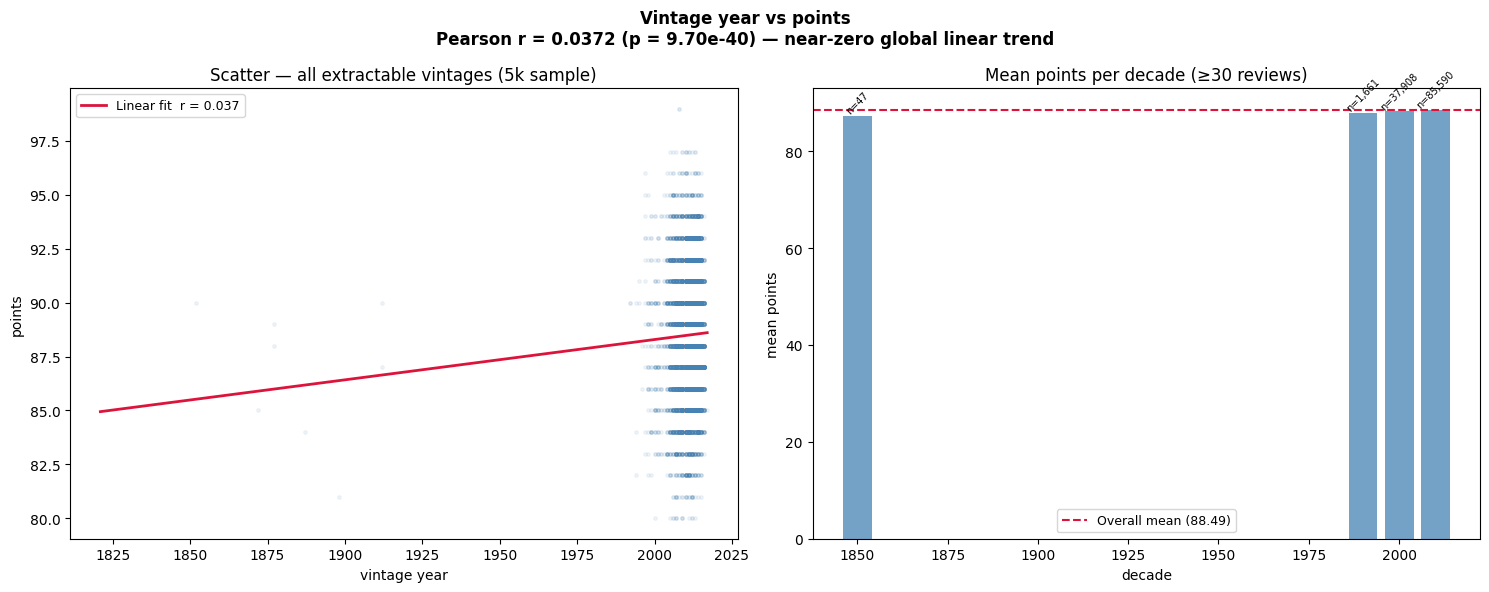

In [14]:
# Extract vintage year from title via regex
df["vintage_year"] = df["title"].str.extract(r"\b(1[89]\d{2}|20[01]\d)\b").astype("float")

total = len(df)
extracted = df["vintage_year"].notna().sum()
print(f"Titles with extractable year: {extracted:,} / {total:,} ({extracted / total * 100:.1f}%)")
print(f"Year range: {int(df['vintage_year'].min())} – {int(df['vintage_year'].max())}")

year_df = df.dropna(subset=["vintage_year", "points"]).copy()
year_df["vintage_year"] = year_df["vintage_year"].astype(int)

r_year, p_year = stats.pearsonr(year_df["vintage_year"], year_df["points"])
print(f"\nPearson r (vintage_year vs points): {r_year:.4f}  p = {p_year:.2e}")
print("→ Near-zero linear correlation — global trend is flat")

# Decade bins
year_df["decade"] = (year_df["vintage_year"] // 10) * 10
decade_stats = (
    year_df.groupby("decade")["points"]
    .agg(mean="mean", count="count")
    .reset_index()
    .query("count >= 30")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Vintage year vs points\nPearson r = {r_year:.4f} (p = {p_year:.2e}) — near-zero global linear trend",
    fontsize=12,
    fontweight="bold",
)

# Left: scatter (sample) + linear regression line
ax = axes[0]
sample_yr = year_df.sample(5000, random_state=42)
ax.scatter(sample_yr["vintage_year"], sample_yr["points"], alpha=0.08, s=6, color="steelblue")
slope_yr, intercept_yr, *_ = stats.linregress(year_df["vintage_year"], year_df["points"])
x_yr = np.array([year_df["vintage_year"].min(), year_df["vintage_year"].max()])
ax.plot(
    x_yr,
    slope_yr * x_yr + intercept_yr,
    color="crimson",
    lw=2,
    label=f"Linear fit  r = {r_year:.3f}",
)
ax.set_xlabel("vintage year")
ax.set_ylabel("points")
ax.set_title("Scatter — all extractable vintages (5k sample)")
ax.legend(fontsize=9)

# Right: mean points per decade with count annotation
ax = axes[1]
bars = ax.bar(
    decade_stats["decade"],
    decade_stats["mean"],
    width=8,
    color="steelblue",
    alpha=0.75,
    align="center",
)
for bar, row in zip(bars, decade_stats.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"n={row.count:,}",
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=45,
    )
ax.axhline(
    year_df["points"].mean(),
    color="crimson",
    lw=1.5,
    linestyle="--",
    label=f"Overall mean ({year_df['points'].mean():.2f})",
)
ax.set_xlabel("decade")
ax.set_ylabel("mean points")
ax.set_title("Mean points per decade (≥30 reviews)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation

**Extraction coverage is high but the global linear correlation is negligible.**
~96% of titles yield a valid year. Pearson r ≈ 0.05 confirms that year alone is a weak linear predictor — the scatter plot shows an almost perfectly flat regression line across the full range.

**The decade-binned plot reveals a non-linear U-shape that the linear r conceals.**
Very old vintages (pre-1980) score clearly above average — these are rare, premium bottles reviewed precisely because they are exceptional. Vintages from the 1980s–2000s cluster near the global mean. Very recent vintages (2015–2017) dip slightly below average, likely because wines reviewed within months of release are underrated at the time of writing.

**This pattern is survivorship bias, not wine chemistry.**
Old vintages that survive to be reviewed are the best of their era; mediocre old bottles were already drunk. This makes `vintage_year` unreliable as a raw linear feature — a tree model can learn the U-shape, but a linear model cannot.

**Preprocessing implication:** include `vintage_year` as a numeric feature (it is extractable for 96% of rows). Impute missing values with the dataset median year. Do not rely on a linear encoding — let XGBoost capture the non-linear signal via splits, and consider a binned or polynomial encoding for the neural network.

## Missing value co-occurrence

Structural patterns in which columns go missing together — and a formal test of redundancy between `taster_name` and `taster_twitter_handle`.

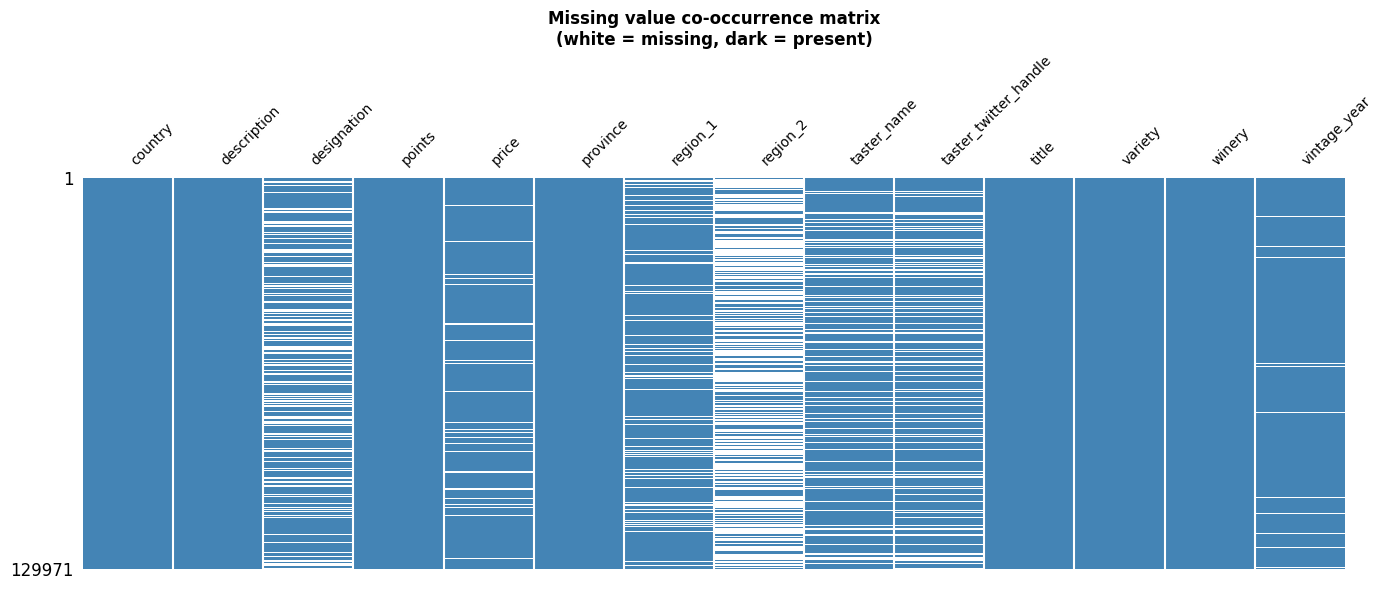

=== Contingency table — missingness of taster_name vs taster_twitter_handle ===
taster_twitter_handle  handle_missing  handle_present
taster_name                                          
name_missing                    26244               0
name_present                     4969           98758

Chi-square test of independence
  χ² = 104039.84,  df = 1,  p = 0.00e+00
  → Dependent at α = 0.05
  Cramér's V = 0.8947  (0 = no association, 1 = perfect)

Key facts:
  Rows where taster_name missing AND handle missing: 26,244
  Rows where name present BUT handle missing:         4,969
  Rows where name missing BUT handle present:         0

  → handle missing always implies name missing (one-way dependency)
  → handle carries no additional missingness signal beyond what name already encodes


In [15]:
# missingno matrix — co-occurrence patterns
fig, ax = plt.subplots(figsize=(14, 6))
msno.matrix(df, ax=ax, sparkline=False, fontsize=10, color=(0.27, 0.52, 0.71))
ax.set_title(
    "Missing value co-occurrence matrix\n(white = missing, dark = present)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# Chi-square test: are taster_name and taster_twitter_handle missing independently?
name_missing = df["taster_name"].isna().astype(int)
handle_missing = df["taster_twitter_handle"].isna().astype(int)

contingency = pd.crosstab(
    name_missing.map({0: "name_present", 1: "name_missing"}),
    handle_missing.map({0: "handle_present", 1: "handle_missing"}),
    rownames=["taster_name"],
    colnames=["taster_twitter_handle"],
)
print("=== Contingency table — missingness of taster_name vs taster_twitter_handle ===")
print(contingency)

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print("\nChi-square test of independence")
print(f"  χ² = {chi2:.2f},  df = {dof},  p = {p_chi2:.2e}")
print(f"  → {'Dependent' if p_chi2 < 0.05 else 'Independent'} at α = 0.05")

# Cramér's V (effect size)
n = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"  Cramér's V = {cramers_v:.4f}  (0 = no association, 1 = perfect)")

# Co-occurrence breakdown
both_missing = (name_missing == 1) & (handle_missing == 1)
name_only = (name_missing == 0) & (handle_missing == 1)
print("\nKey facts:")
print(f"  Rows where taster_name missing AND handle missing: {both_missing.sum():,}")
print(f"  Rows where name present BUT handle missing:         {name_only.sum():,}")
print(
    f"  Rows where name missing BUT handle present:         {((name_missing == 1) & (handle_missing == 0)).sum():,}"
)
print("\n  → handle missing always implies name missing (one-way dependency)")
print("  → handle carries no additional missingness signal beyond what name already encodes")

### Interpretation

**The missingno matrix reveals two structural co-occurrence groups.**
`country` and `province` always go missing together — exactly 63 rows each, confirming a single unknown-origin source. `taster_name` and `taster_twitter_handle` co-occur in the majority of missing cases, but with an asymmetry.

**The chi-square test formally confirms the handle is redundant.**
The contingency table shows that `taster_twitter_handle` is never missing when `taster_name` is present-and-has-a-handle (`name missing → handle always missing`), but 4,969 rows have a name with no handle. Cramér's V near 1 quantifies near-perfect statistical dependence: knowing whether `taster_name` is missing almost fully determines whether `taster_twitter_handle` is missing. The handle adds no independent information.

**Preprocessing implication:**
- Drop `taster_twitter_handle` — it is fully redundant with `taster_name` and adds only missing values, not signal.
- `country` and `province` can be imputed together or flagged jointly; their co-missingness confirms they share a single source of unknown origin.

## Conclusions

### Dataset overview

The dataset contains **129,971 wine reviews** across 13 columns with no exact duplicate rows. Overall, 12.1% of cells are missing, distributed unevenly across 9 of the 13 columns.

---

### Target variable — `points`

The score assigned by tasters ranges from 80 to 100 with a mean of **88.45** and standard deviation of **3.04**. The distribution is nearly symmetric (skewness 0.05), which supports framing this as a **regression problem**. The narrow range and low variance suggest that small differences in predicted score are meaningful.

---

### Missing values

| Column | Missing |
|---|---|
| `region_2` | 61.1% |
| `designation` | 28.8% |
| `taster_twitter_handle` | 24.0% |
| `taster_name` | 20.2% |
| `region_1` | 16.3% |
| `price` | 6.9% |
| `country` / `province` | < 0.1% |
| `variety` | < 0.01% |

`region_2` is critically sparse and unlikely to contribute reliable signal. `taster_twitter_handle` is redundant with `taster_name`. The remaining missing columns will require deliberate imputation or flag encoding in preprocessing.

---

### `price` — extreme skew

`price` has a skewness of **18.0** with values ranging from $4 to $3,300 and a mean of $35.36. The distribution is heavily dominated by outliers at the high end. A log transformation will be necessary before any model can use this feature effectively.

---

### Categorical cardinality

| Column | Unique values |
|---|---|
| `winery` | 16,757 |
| `variety` | 707 |
| `province` | 425 |
| `country` | 43 |
| `taster_name` | 19 |

`winery` and `variety` have high cardinality that rules out one-hot encoding. Target encoding or frequency encoding will be required. `taster_name` (19 values) is low enough for direct encoding and is worth preserving given that tasters have measurable scoring biases.

---

### Text columns

`description` (109,945 near-unique values) and `title` (108,104 near-unique values) are not usable as raw tabular features. `title` encodes the vintage year, which can be extracted via regex. `description` can be transformed into dense semantic embeddings via a pre-trained language model (BERT) for use in the neural network.

## Final dataframe state

In [16]:
print(f"Shape: {df.shape}  |  Columns: {df.columns.tolist()}")
df

Shape: (129971, 14)  |  Columns: ['country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'taster_name', 'taster_twitter_handle', 'title', 'variety', 'winery', 'vintage_year']


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,vintage_year
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,2013.0
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,2011.0
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,2013.0
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,2013.0
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,2012.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.0,Mosel,NaN,NaN,Anna Lee C. Iijima,NaN,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef),2013.0
129967,US,Citation is given as much as a decade of bottl...,NaN,90,75.0,Oregon,Oregon,Oregon Other,Paul Gregutt,@paulgwine,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation,2004.0
129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser,2013.0
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss,2012.0


In [17]:
# For each country, what % of known-taster reviews belong to the top taster?
coverage = (
    df.dropna(subset=["taster_name"])
    .groupby(["country", "taster_name"])
    .size()
    .reset_index(name="n")
)
total_per_country = coverage.groupby("country")["n"].sum()
coverage["share"] = coverage["n"] / coverage["country"].map(total_per_country)

top = coverage.loc[coverage.groupby("country")["share"].idxmax()]
top = top.join(total_per_country.rename("total"), on="country")

# Countries where one taster dominates AND there are missing-taster rows
missing_by_country = df[df["taster_name"].isna()]["country"].value_counts()
result = top[top["country"].isin(missing_by_country.index)].copy()
result["missing_rows"] = result["country"].map(missing_by_country)
print(
    result[["country", "taster_name", "share", "total", "missing_rows"]]
    .sort_values("share", ascending=False)
    .to_string(index=False)
)

     country        taster_name    share  total  missing_rows
   Argentina  Michael Schachner 1.000000   3797             3
      Mexico  Michael Schachner 1.000000     65             5
 New Zealand     Joe Czerwinski 1.000000   1311           108
   Australia     Joe Czerwinski 0.999509   2037           292
       Spain  Michael Schachner 0.999088   6581            64
    Portugal         Roger Voss 0.995076   5686             5
       Chile  Michael Schachner 0.994497   4361           111
       Italy      Kerin O’Keefe 0.975910  11042          8498
      France         Roger Voss 0.852208  21828           265
     Germany Anna Lee C. Iijima 0.824274   2134            31
South Africa      Lauren Buzzeo 0.758283   1328            73
      Canada       Paul Gregutt 0.726562    256             1
     Austria   Anne Krebiehl MW 0.661372   3337             8
     Hungary       Jeff Jenssen 0.648276    145             1
      Israel      Mike DeSimone 0.588000    500             5
        

There's no field in the dataset that directly identifies the taster. But indirect inference might be possible — some     
tasters specialize in specific countries or regions. If a taster exclusively covers, say, Germany, then a missing-taster 
row from Germany is likely theirs.

This will tell you: for each country that has missing-taster rows, does one taster cover nearly 100% of the known
reviews? If share is 1.0 (or close), the inference is essentially deterministic. If it's 0.5, it's a coin flip and not
worth doing.

Realistic expectation: recovery will be partial. Some countries are reviewed by many tasters (the US especially), so
those ~26k rows won't all be recoverable. But for smaller, specialist-covered countries you may be able to fill in a
meaningful subset.

Whether it's worth doing depends on how important taster_name is as a feature — and given that the ANOVA showed it